# Figure 2 — Time reproduction in MS and control groups

Reproduces the model-based panels of Figure 2:

* **A, B** average reproduced time vs. presented interval for control (A) and MS (B), with the group mean regression line, the identity line, and the grey **Bayesian-observer model simulation** (mean +/- SD) from the pooled fit.
* **C, D** per-subject regression **slope** (C) and **intercept** (D) beeswarms.

**Inputs:** `results/pooled_params.pkl` (`python scripts/fit_pooled.py`) and `results/subject_params.csv` (`python scripts/fit_all_subjects.py`).

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd()
_root = _root if (_root / "mstiming").exists() else _root.parent
sys.path.insert(0, str(_root))

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mstiming import config, data_io, fitting, plotting, stats
plotting.setup_style()

for pth, script in [(config.POOLED_PARAMS_PKL, "fit_pooled.py"),
                    (config.SUBJECT_PARAMS_CSV, "fit_all_subjects.py")]:
    if not pth.exists():
        raise FileNotFoundError(f"Missing {pth.name} -- run: python scripts/{script}")

trials = data_io.load_trials()
cohort = data_io.load_cohort()
params = pd.read_csv(config.SUBJECT_PARAMS_CSV)
with open(config.POOLED_PARAMS_PKL, "rb") as f:
    pooled = pickle.load(f)
pooled

{'CN': {'w_m': np.float64(0.31833851537402247),
  'w_r': np.float64(0.31801024548356416),
  'alpha': np.float64(0.9609064903476683),
  'nll': 9666.335343702747,
  'success': True,
  'n_iter': 51,
  'n_fev': 95,
  'n_trials': 31370},
 'MS': {'w_m': np.float64(0.3616712045689616),
  'w_r': np.float64(0.36639145751417035),
  'alpha': np.float64(0.9407828236386436),
  'nll': 7455.891018360755,
  'success': True,
  'n_iter': 52,
  'n_fev': 95,
  'n_trials': 17521}}

## A, B — reproduced time vs. interval with model simulation
The regression line uses each group's mean per-subject slope and intercept (shown in the legend, matching the published panels).

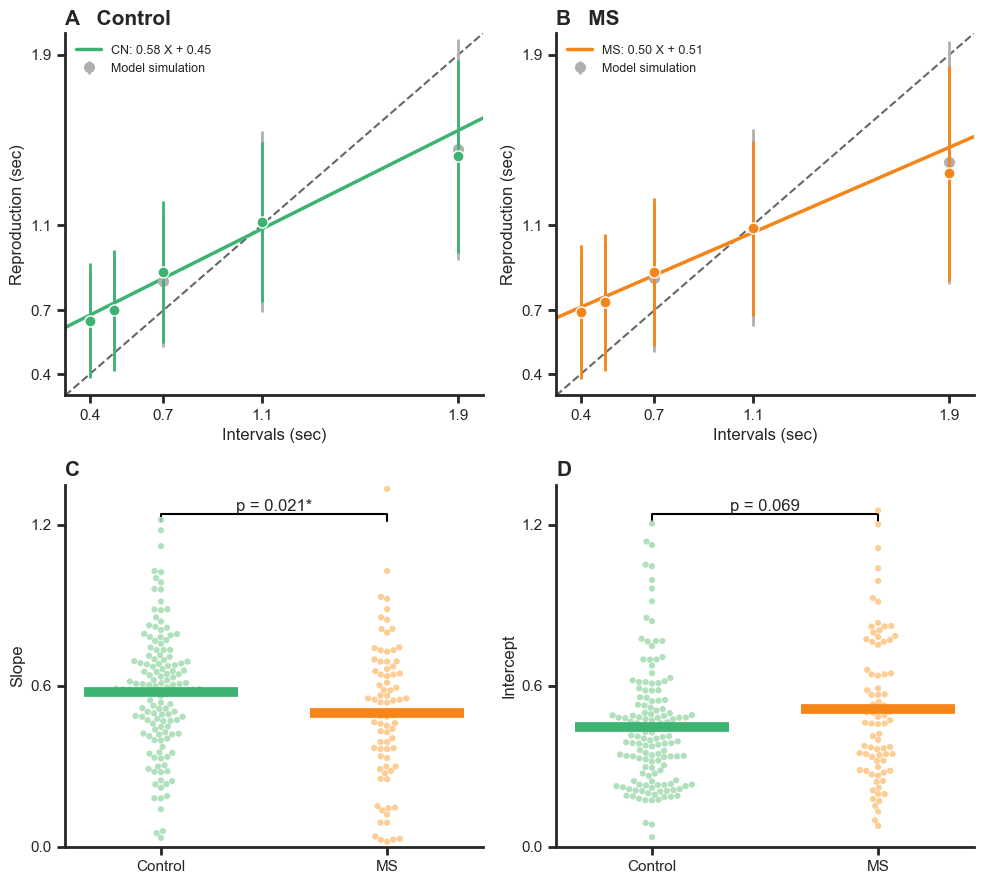

slope: t-test p=0.021
intercept: Mann-Whitney U p=0.069


In [2]:

fig, axes = plt.subplots(2, 2, figsize=(10, 9))

for ax, gcode, disp in [(axes[0, 0], "CN", "Control"), (axes[0, 1], "MS", "MS")]:
    tt = data_io.group_pooled_trials(trials, cohort, gcode)
    mu, sd = data_io.group_means(tt)
    ints, sim_mu, sim_sd = fitting.simulate(tt, pooled[gcode], seed=config.SIM_SEED)
    sub = params[params.group == disp]
    slope, intercept = sub["slope"].mean(), sub["intercept"].mean()
    plotting.model_over_data(ax, disp, mu.index.values, mu.values, sd.values,
                             sim_mu, sim_sd, slope, intercept)

# --- C, D per-subject slope and intercept ------------------------------------
slope_res = stats.compare_two_groups(params.loc[params.group == "Control", "slope"],
                                     params.loc[params.group == "MS", "slope"])
int_res = stats.compare_two_groups(params.loc[params.group == "Control", "intercept"],
                                   params.loc[params.group == "MS", "intercept"])
plotting.beeswarm_mean(axes[1, 0], params, "slope", ylabel="Slope",
                       ylim=(0, 1.35), yticks=[0, 0.6, 1.2], pval=slope_res["p"])
plotting.beeswarm_mean(axes[1, 1], params, "intercept", ylabel="Intercept",
                       ylim=(0, 1.35), yticks=[0, 0.6, 1.2], pval=int_res["p"])

titles = ["A   Control", "B   MS", "C", "D"]
for ax, t in zip(axes.ravel(), titles):
    ax.set_title(t, loc="left", fontweight="bold", fontsize=15)
fig.tight_layout()
config.FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(config.FIG_DIR / "Figure2.pdf", bbox_inches="tight")
fig.savefig(config.FIG_DIR / "Figure2.png", dpi=300, bbox_inches="tight")
plt.show()
print("slope:", slope_res["test"], "p=%.3f" % slope_res["p"])
print("intercept:", int_res["test"], "p=%.3f" % int_res["p"])

### Goodness of fit
$R^2$ between the pooled data means and the model-simulated means per interval.

In [3]:

from sklearn.metrics import r2_score
for gcode, disp in [("CN", "Control"), ("MS", "MS")]:
    tt = data_io.group_pooled_trials(trials, cohort, gcode)
    mu, _ = data_io.group_means(tt)
    _, sim_mu, _ = fitting.simulate(tt, pooled[gcode], seed=config.SIM_SEED)
    print(f"{disp}: R^2 = {r2_score(mu.values, sim_mu):.3f}")

Control: R^2 = 0.993


MS: R^2 = 0.988
